# Test spectrum of a system

0.9894573643995105 1.0438224586935674
Ratio B/A =  4.0
1.459805452112948
np.nanmedian(flB_interp) 1.0804094391372197


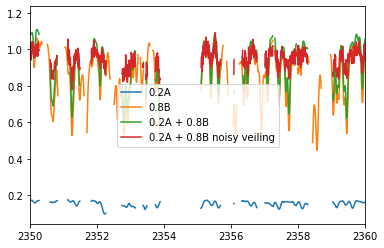

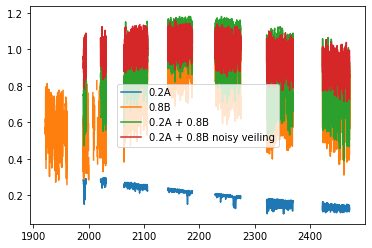

In [9]:
# make test spectrum of system: 
# B flux 4x higher than A flux so 20% ROXs12A + 80% 2M0355 analog

import numpy as np
import matplotlib.pyplot as plt

def load_spec_file(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=file[:,0]
    fl=file[:,1]
    err=file[:,2]
    return wl,fl,err

flA = np.loadtxt('/home/natalie/Desktop/atm_retrieval/CRIRES/ROXs12A/ROXs12A_dataflux_wslope.txt')
wlA,_,flerrA=load_spec_file('/home/natalie/Desktop/atm_retrieval/CRIRES/ROXs12A/ROXs12A_spectrum.txt')
wlB,flB,flerrB = load_spec_file('/home/natalie/Desktop/atm_retrieval/CRIRES/test/test_spectrum.txt')

# interpolate wl of B onto A
flB_interp = np.interp(wlA, wlB, flB)
errB_interp = np.interp(wlA, wlB, flerrB)
print(np.nanmean(flA),np.nanmean(flB))

# add A+B
ratioA = 0.2 # for testing other scenarios
ratioB = 1-ratioA
print('Ratio B/A = ',ratioB/ratioA)
flux = ratioA*flA+ratioB*flB_interp
err = np.sqrt(flerrA**2+errB_interp**2)
flux/=np.nanmedian(flux)

rA = np.reshape(ratioA*flA,(7,3,2048))
rB = np.reshape(ratioB*flB_interp,(7,3,2048))
print((1+np.nanmean(rA[1,0]/rB[1,0])))

# add noise
random_noise=np.random.normal(0,0.2*np.nanstd(flux),size=flux.shape)
flux_noisy = flux + random_noise
flux_noisy/=np.nanmedian(flux_noisy)

# add veiling
log_k_rk = -3.0
d_rk = 2.0
wl_mid =  np.median(wlA)
rk_func = lambda x: 10**log_k_rk*np.array(x-wl_mid) + d_rk
rk = rk_func(wlA)
print('np.nanmedian(flB_interp)',np.nanmedian(flB_interp))
flB_veiling = ((flB_interp+rk*np.nanmedian(flB_interp))/(1+rk))
flux_veiling = ratioA*flA+ratioB*flB_veiling
flux_veiling/=np.nanmedian(flux_veiling)

# noise AND veiling
flux_veiling_noisy = flux_veiling + random_noise
flux_veiling_noisy/=np.nanmedian(flux_veiling_noisy)

plt.plot(wlA,ratioA*flA,label=f'{ratioA}A')
plt.plot(wlA,ratioB*flB_interp,label=f'{ratioB}B')
#plt.plot(wlA,flux_noisy,label=f'{ratioA}A + {ratioB}B noisy')
plt.plot(wlA,flux,label=f'{ratioA}A + {ratioB}B')
plt.plot(wlA,flux_veiling_noisy,label=f'{ratioA}A + {ratioB}B noisy veiling')
#plt.plot(wlA,flux_veiling,label=f'{ratioA}A + {ratioB}B veiling')
plt.xlim(2350,2360)
plt.legend()
plt.show()

#print('S/N of noisy flux = ',np.nanmedian(flux_noisy/np.nanstd(flux_noisy)))
save=False
if save:
    spectrum=np.full(shape=(3*7*2048,3),fill_value=np.nan)
    spectrum[:,0]=wlA
    spectrum[:,1]=flux
    spectrum[:,2]=err.flatten()
    np.savetxt('./CRIRES/testsys/testsys_spectrum.txt',spectrum,delimiter=' ',header='wavelength(nm) flux flux_error')
    spectrum[:,1]=flux_noisy
    np.savetxt('./CRIRES/testsys/testsys_spectrum_noisy.txt',spectrum,delimiter=' ',header='wavelength(nm) flux flux_error')
    spectrum[:,1]=flux_veiling
    np.savetxt('./CRIRES/testsys/testsys_spectrum_veiling.txt',spectrum,delimiter=' ',header='wavelength(nm) flux flux_error')
    spectrum[:,1]=flux_veiling_noisy
    np.savetxt('./CRIRES/testsys/testsys_spectrum_veiling_noisy.txt',spectrum,delimiter=' ',header='wavelength(nm) flux flux_error')


plt.plot(wlA,ratioA*flA,label=f'{ratioA}A')
plt.plot(wlA,ratioB*flB_interp,label=f'{ratioB}B')
#plt.plot(wlA,flux_noisy,label=f'{ratioA}A + {ratioB}B noisy')
plt.plot(wlA,flux,label=f'{ratioA}A + {ratioB}B')
plt.plot(wlA,flux_veiling_noisy,label=f'{ratioA}A + {ratioB}B noisy veiling')
#plt.plot(wlA,flux_veiling,label=f'{ratioA}A + {ratioB}B veiling')
plt.legend()
plt.show()

test = False
if test:
    # test if correct ratio can be retrieved
    from scipy.optimize import nnls

    # ignore nans for least squares
    nonans = np.isfinite(flux) & np.isfinite(flA) & np.isfinite(flB_interp) & np.isfinite(flerrA) & np.isfinite(errB_interp)
    M = np.vstack([flA[nonans], flB[nonans]]).T # create model matrix, shape (2, N)
    d = flux[nonans] # data
    inv_cov = np.diag(1/err[nonans]**2) # define inverse of covariance matrix

    # set up equation to solve (see Ruffio+2019 Appendix A)
    lhs = M.T @ inv_cov @ M # left-hand side
    rhs = M.T @ inv_cov @ d # right-hand side
    phi, _ = nnls(lhs, rhs)
    print(f'A={np.round(phi[0]*100,decimals=2)}%')
    print(f'B={np.round(phi[1]*100,decimals=2)}%')

In [1]:
10**1.8

63.09573444801933

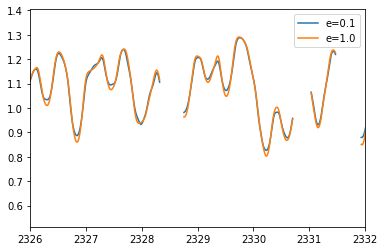

In [ ]:
# check what limb darkening actually does to the spectrum
from PyAstronomy.pyasl import fastRotBroad
waves_even = np.linspace(np.min(wlB), np.max(wlB), wlB.size)
flB_even = np.interp(waves_even, wlB, flB)

vsini = 20.0
epsilon_limb1 = 0.1
spec1 = fastRotBroad(waves_even,flB_even, epsilon_limb1, vsini)
epsilon_limb2 = 1.0
spec2 = fastRotBroad(waves_even,flB_even, epsilon_limb2, vsini)

plt.plot(waves_even,spec1,label=f'e={epsilon_limb1}')
plt.plot(waves_even,spec2,label=f'e={epsilon_limb2}')
plt.xlim(2326,2332)
plt.legend()
plt.show()

# Other

In [1]:
# spectral resolution

from target import Target
bd = Target('ROXs12A')
wl,fl,err = bd.load_spectrum()
res = bd.calc_resolution()
print(res) # mean
print(bd.spec_resolution) # all order/dets

63088.33998377872
[[59715.61116754 62974.89338345 66760.03257009]
 [59744.87789753 63036.87023503 66853.63374988]
 [59799.19780577 63061.49268731 66855.46321002]
 [59849.43383351 63088.33998378 66869.18642593]
 [59890.6650157  63139.14285322 66908.99453152]
 [59932.13264088 63190.48324078 66959.06158776]
 [59974.65773933 63273.27416509 67044.81768477]]


# CMD

<ipython-input-2-ab065dca7cff>:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_J[np.isnan(all_J)] = data[np.isnan(all_J)]['J_2MASS']
<ipython-input-2-ab065dca7cff>:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_J[np.isnan(all_J)] = data[np.isnan(all_J)]['J_2MASS']
<ipython-input-2-ab065dca7cff>:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_K[np.isnan(all_K)] = data[np.isnan(all_K)]['Ks_2MASS']
<ipython-input-2-ab06

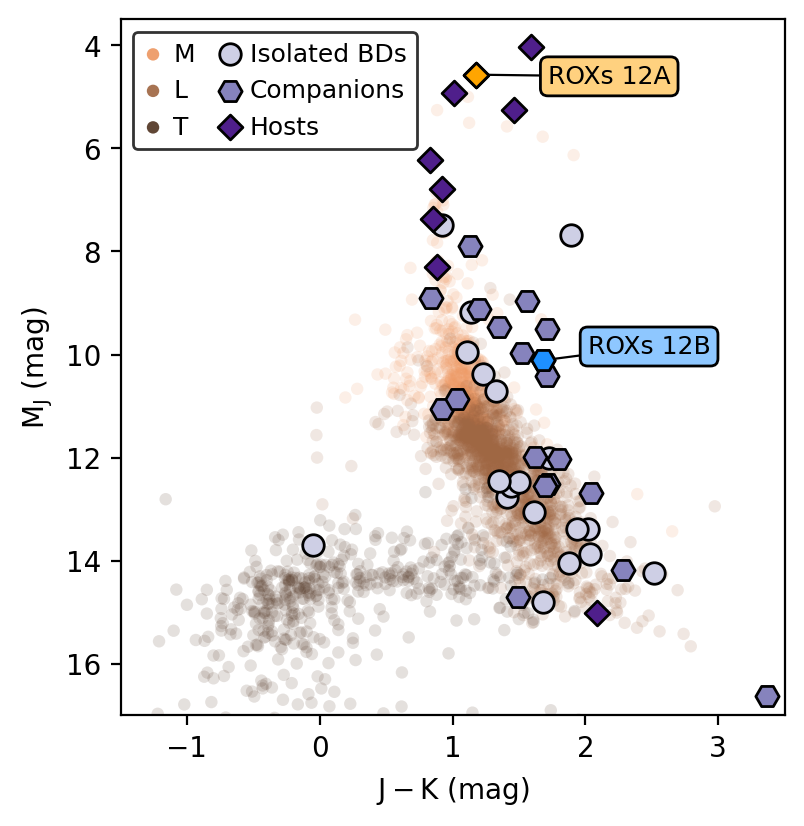

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors
import os
os.environ['pRT_input_data_path'] = "/home/natalie/.local/lib/python3.8/site-packages/petitRADTRANS/input_data_std/input_data"
from target import Target

# Load the Ultracool dwarfs sample
Ultracool_data = pd.read_csv('./UltracoolSheet_Main.csv')

SupJup_data = [
    # Name, alternative name, J_MKO, J_2MASS, K_MKO, Ks_2MASS, dist_formula, has_higher_mass_companion, separation, mass
    ['HD 1160B',                     'HD 1160B',       15.83,  np.nan, 14.12,  np.nan, 120.9, 'HD 1160A',      80,     np.nan], 
    ['HD 1160C',                     'HD 1160C',       13.31,  np.nan, 12.18,  np.nan, 120.9, 'HD 1160A',      530,    np.nan], 
    ['2MASS J02192210-3925225A',     '2M 0219A',       11.32,  np.nan, 10.44,  np.nan, 40.2,  '>2M 0219B',     -156,   np.nan], 
    ['2MASS J02192210-3925225B',     '2M 0219B',       15.54,  np.nan, 13.82,  np.nan, 40.2,  '2M 0219A',      156,    np.nan], 
    ['AB Pic b',                     'AB Pic b',       16.18,  np.nan, 14.14,  np.nan, 50.14, 'AB Pic',        273,    np.nan], 
   #['PZ Tel A',                     'PZ Tel A',       6.86,   np.nan, 6.38,   np.nan, 47.13, '>PZ Tel B',     -25,    np.nan], 
    ['PZ Tel B',                     'PZ Tel B',       12.26,  np.nan, 11.42,  np.nan, 47.13, 'PZ Tel A',      25,     np.nan], 
    ['2MASS J01225093-2439505A',     '2M 0122A',       10.02,  np.nan, 9.17,   np.nan, 33.74, '>2M 0122B',     -52,    np.nan], 
    ['2MASS J01225093-2439505B',     '2M 0122B',       16.81,  np.nan, 14.53,  np.nan, 33.74, '2M 0122A',      52,     np.nan], 
    ['2MASS J03552337+1133437',      '2M 0355',        np.nan, 14.05,  np.nan, 11.53,  9.16,  'N',             np.nan, np.nan], 
    ['LSPM J0036+1821',              'LSPM J0036',     np.nan, 12.47,  np.nan, 11.06,  8.74,  'N',             np.nan, np.nan], 
    ['2MASS J01033563-5515561(AB)',  '2M 0103(AB)',    10.16,  np.nan, 9.24,   np.nan, 47.21, '>2M 0103(AB)b', -84,    np.nan], 
    ['2MASS J01033563-5515561(AB)b', '2M 0103(AB)b',   15.4,   np.nan, 13.6,   np.nan, 47.21, '2M 0103(AB)',   84,     np.nan], 
    ['DENIS J025503.3-470049',       'DENIS J0255',    np.nan, 13.24,  np.nan, 11.56,  4.868, 'N',             np.nan, np.nan], 
    ['CD-35 2722A',                  'CD-35 2722A',    np.nan, 7.86,   np.nan, 7.03,   21.3,  '>CD-35 2722B',  -67,    np.nan], 
    ['CD-35 2722B',                  'CD-35 2722B',    13.63,  np.nan, 12.01,  np.nan, 21.3,  'CD-35 2722A',   67,     np.nan], 
    ['DH Tau A',                     'DH Tau A',       9.77,   np.nan, 8.18,   np.nan, 140,   '>DH Tau B',     -328.2, np.nan], 
    ['DH Tau B',                     'DH Tau B',       15.71,  np.nan, 14.19,  np.nan, 140,   'DH Tau A',      328.2,  np.nan], 
    ['Luhman 16A',                   'Luhman 16A',     11.53,  np.nan, 9.44,   np.nan, 2.02,  '>Luhman 16B',   -3.12,  np.nan], 
    ['Luhman 16B',                   'Luhman 16B',     11.22,  np.nan, 9.73,   np.nan, 2.02,  'Luhman 16A',    3.12,   np.nan], 
    ['FU Tau A',                     'FU Tau A',       10.78,  np.nan, 9.32,   np.nan, 127.6, '>FU Tau B',     -800,   np.nan], 
    ['FU Tau B',                     'FU Tau B',       15.04,  np.nan, 13.33,  np.nan, 127.6, 'FU Tau A',      800,    np.nan], 
    ['HR 3549',                      'HR 3549B',       15.94,  np.nan, 15.02,  np.nan, 94.8,  'HR 3549',       80,     np.nan], # Uses H-band magnitude for K-band
   #['HR 3549',                      'HR 3549B',       15.94,  np.nan, 14.7,   np.nan, 94.8,  'HR 3549',       80,     np.nan], # Extrapolated J and H-band magnitudes
    ['2MASS J08354256-0819237',      '2M 0835',        np.nan, 13.17,  np.nan, 11.136, 7.23,  'N',             np.nan, np.nan], 
    ['beta Pic b',                   r'$\beta$ Pic b', 14.00,  np.nan, 12.30,  np.nan, 19.44, 'beta Pic A',    10.6,   np.nan], 
    ['2MASS J01415823-4633574',      '2M 0141',        np.nan, 14.83,  np.nan, 13.10,  36.65, 'N',             np.nan, np.nan], 
    ['2MASS J05233822-1403022',      '2M 0523',        np.nan, 13.08,  np.nan, 11.638, 12.73, 'N',             np.nan, np.nan], 
    ['SSSPM J0829-1309',             '2M 0829',        np.nan, 12.80,  np.nan, 11.30,  11.68, 'N',             np.nan, np.nan], 
    ['2MASS J04341527+2250309',      '2M 0434',        np.nan, 13.74,  np.nan, 11.85,  163,   'N',             np.nan, np.nan], 
    ['2MASS J05012406-0010452',      '2M 0501',        np.nan, 14.98,  np.nan, 12.96,  20.9,  'N',             np.nan, np.nan], 
    ['2MASS J05591914-1404488',      '2M 0559',        np.nan, 13.80,  np.nan, 13.85,  10.50, 'N',             np.nan, np.nan], 
    ['2MASS J11553952-3727350',      '2M 1155',        np.nan, 12.81,  np.nan, 11.46,  11.80, 'N',             np.nan, np.nan], 
    ['2MASS J14252798-3650229',      '2M 1425',        np.nan, 13.75,  np.nan, 11.81,  11.85, 'N',             np.nan, np.nan], 
    ['DENIS J060852.8-275358',       '2M 0608',        np.nan, 13.60,  np.nan, 12.37,  44.2,  'N',             np.nan, np.nan], 
    ['CD-33 7795A',                  'TWA 5A',         8.40,   np.nan, 7.39,   np.nan, 49.6,  '>TWA 5B',       -86,    np.nan], 
    ['CD-33 7795B',                  'TWA 5B',         12.6,   np.nan, 11.4,   np.nan, 49.6,  'TWA 5A',        86,     np.nan], 
    ['HIP 64892B',                   'HIP 64892B',     14.85,  np.nan, 13.50,  np.nan, 119.6, 'HIP 64892A',    159,    np.nan], 
   #['YSES 1b',                      'YSES 1b',        16.27,  np.nan, 14.70,  np.nan, 94.2,  'YSES 1A',       162,    np.nan], 
   #['YSES 1b',                      'YSES 1b',        15.73,  np.nan, 14.44,  np.nan, 94.2,  'YSES 1A',       162,    np.nan], 
    ['YSES 1b',                      'YSES 1b',        15.73,  np.nan, 14.70,  np.nan, 94.2,  'YSES 1A',       162,    np.nan], 
   #['YSES 1b',                      'YSES 1b',        14.16,  np.nan, 14.31,  np.nan, 94.2,  'YSES 1A',       162,    np.nan], # J, Ks mag from (K1,K2)+species
   #['YSES 1c',                      'YSES 1c',        21.17,  np.nan, 17.85,  np.nan, 94.2,  'YSES 1A',       320,    np.nan], 
   #['YSES 1c',                      'YSES 1c',        21.17,  np.nan, 18.34,  np.nan, 94.2,  'YSES 1A',       320,    np.nan], 
    ['YSES 1c',                      'YSES 1c',        21.50,  np.nan, 18.13,  np.nan, 94.2,  'YSES 1A',       320,    np.nan], # J, Ks mag from (K1,K2)+species
    ['2MASS J05002100+0330501',      '2M 0500',        np.nan, 13.67,  np.nan, 12.06,  13.23, 'N',             np.nan, np.nan], 
    ['2MASS J06244595-4521548',      '2M 0624',        np.nan, 14.48,  np.nan, 12.60,  12.19, 'N',             np.nan, np.nan], 
   #['GQ Lup A',                     'GQ Lup A',       8.69,   np.nan, 7.10,   np.nan, 154.1, '>GQ Lup B',     -105,   np.nan], 
    ['GQ Lup B',                     'GQ Lup B',       14.90,  np.nan, 13.34,  np.nan, 154.1, 'GQ Lup A',      105,    np.nan], 
    ['ROXs 12A',                     'ROXs 12A',       10.28,  np.nan, 9.10,   np.nan, 138.6, '>ROXs 12B',     -210,   np.nan], 
    ['ROXs 12B',                     'ROXs 12B',       15.82,  np.nan, 14.14,  np.nan, 138.6, 'ROXs 12A',      210,    np.nan], 
    ['TWA 28',                       'TWA 28',         np.nan, 13.03,  np.nan, 11.89,  59.2,  'N',             np.nan, np.nan], 
    ['2MASS J08561384-1342242',      '2M 0856',        np.nan, 13.60,  np.nan, 12.49,  53.8,  'N',             np.nan, np.nan], 
    ['2MASSI J0953212-101420',       '2M 0953',        np.nan, 13.47,  np.nan, 12.14,  35.7,  'N',             np.nan, np.nan], 
    ['2MASS J12003792-7845082',      '2M 1200',        np.nan, 12.52,  np.nan, 11.60,  101.6, 'N',             np.nan, np.nan], 
]

SupJup_data = pd.DataFrame(
    SupJup_data, 
    columns=[
        'name', 'alt_name', 
        'J_MKO', 'J_2MASS', 'K_MKO', 'Ks_2MASS', 
        'dist_formula', 'has_higher_mass_companion', 
        'separation', 'mass'
        ]
    )

# Add to the DataFrame
data = pd.concat([Ultracool_data, SupJup_data])

all_J = data['J_MKO']
all_K = data['K_MKO']

all_J[np.isnan(all_J)] = data[np.isnan(all_J)]['J_2MASS']
all_K[np.isnan(all_K)] = data[np.isnan(all_K)]['Ks_2MASS']

# Get the colors and absolute magnitudes
all_J_K = all_J - all_K
all_MJ = all_J - 5*np.log10(data['dist_formula']/10)
all_MK = all_K - 5*np.log10(data['dist_formula']/10)

# Use only specific brown dwarfs
#vollim_mask = (data['Best20b_vollim_sample']=='Y')
vollim_mask = (data['has_higher_mass_companion']=='N')

# Sub-selections per spectral type
T_dwarfs_mask = (data['sptnumabs_formula']>=20) & (data['sptnumabs_formula']<30)
T_dwarfs_J_K  = all_J_K[T_dwarfs_mask & vollim_mask]
T_dwarfs_MJ   = all_MJ[T_dwarfs_mask & vollim_mask]
T_dwarfs_MK   = all_MK[T_dwarfs_mask & vollim_mask]

L_dwarfs_mask = (data['sptnumabs_formula']>=10) & (data['sptnumabs_formula']<20)
L_dwarfs_J_K  = all_J_K[L_dwarfs_mask & vollim_mask]
L_dwarfs_MJ   = all_MJ[L_dwarfs_mask & vollim_mask]
L_dwarfs_MK   = all_MK[L_dwarfs_mask & vollim_mask]

M_dwarfs_mask = (data['sptnumabs_formula']>=0) & (data['sptnumabs_formula']<10)
#M_dwarfs_mask = (data['sptnumabs_formula']==-100)
M_dwarfs_J_K  = all_J_K[M_dwarfs_mask & vollim_mask]
M_dwarfs_MJ   = all_MJ[M_dwarfs_mask & vollim_mask]
M_dwarfs_MK   = all_MK[M_dwarfs_mask & vollim_mask]

# Only the targets in the SupJup survey
SupJup_mask = np.vectorize(isinstance)(data['alt_name'], str)

# Is part of a multiple system
SupJup_is_multi = (SupJup_mask & (data['has_higher_mass_companion'] != 'N'))
SupJup_is_not_multi = (SupJup_mask & ~(data['has_higher_mass_companion'] != 'N'))

# Is either the host or a companion
SupJup_is_host      = (SupJup_mask & np.array([item.startswith('>') for item in data['has_higher_mass_companion']]))
SupJup_is_companion = (SupJup_mask & np.array([(not item.startswith('>')) and (item != 'N') for item in data['has_higher_mass_companion']]))

cmap = plt.get_cmap('Purples')
c_isolated = cmap(0.3)
c_companion = cmap(0.6)
c_host = cmap(0.9)

fig, ax = plt.subplots(figsize=(4,4), gridspec_kw={'left':0.13, 'right':0.96, 'bottom':0.09, 'top':0.96}, dpi=200)

title_proxy = mpl.patches.Rectangle((0,0), 0, 0, color='w')
color_axis = '0.0'
color_data = '0.0'
for ax_i in [ax]:
    ax_i.set_facecolor('none')
    
    ax_i.spines['bottom'].set_color(color_axis)
    ax_i.spines['top'].set_color(color_axis)
    ax_i.spines['right'].set_color(color_axis)
    ax_i.spines['left'].set_color(color_axis)

    ax_i.tick_params(axis='x', colors=color_axis)
    ax_i.tick_params(axis='y', colors=color_axis)
    ax_i.yaxis.label.set_color(color_axis)
    ax_i.xaxis.label.set_color(color_axis)
    pass

cmap=mpl.colormaps['copper']
ax.scatter(M_dwarfs_J_K, M_dwarfs_MJ, c=cmap(0.75), ec='none', alpha=0.15, s=20)
ax.scatter(L_dwarfs_J_K, L_dwarfs_MJ, c=cmap(0.5), ec='none', alpha=0.15, s=20)
ax.scatter(T_dwarfs_J_K, T_dwarfs_MJ, c=cmap(0.25), ec='none', alpha=0.15, s=20)
ax.scatter(np.nan, np.nan, c=cmap(0.75), ec='none', alpha=0.90, s=20, label='M')
ax.scatter(np.nan, np.nan, c=cmap(0.5), ec='none', alpha=0.90, s=20, label='L')
ax.scatter(np.nan, np.nan, c=cmap(0.25), ec='none', alpha=0.90, s=20, label='T')

for i in SupJup_data.index:

    val = SupJup_data.iloc[i]
    
    if (val['has_higher_mass_companion'] == 'N'):
        continue
    
    xy_i = (np.array(all_J_K[SupJup_mask])[i], np.array(all_MJ[SupJup_mask])[i])
    
    xytext_i = xy_i
    xytext_i = (xytext_i[0]+0.08, xytext_i[1]-0.08)
    
    name_i = val['name']
    alt_name_i = val['alt_name']
    
    ha, va = 'left', 'bottom'
    arrowprops = None

    c_i = 'r'
    if val['has_higher_mass_companion'] == 'N':
        c_i = mpl.colors.LinearSegmentedColormap.from_list(
            name='_', colors=['w', c_isolated])(0.6)

    elif val['has_higher_mass_companion'].startswith('>'):
        c_i = mpl.colors.LinearSegmentedColormap.from_list(
            name='_', colors=['w', c_host])(0.6)

    elif not val['has_higher_mass_companion'].startswith('>'):
        c_i = mpl.colors.LinearSegmentedColormap.from_list(
            name='_', colors=['w', c_companion])(0.6)

# Isolated brown dwarfs
ax.scatter(all_J_K[SupJup_is_not_multi], all_MJ[SupJup_is_not_multi], 
    color=c_isolated, s=60, ec=color_data, marker='o', label='Isolated BDs', zorder=10)

# Companions and hosts
ax.scatter(all_J_K[SupJup_is_companion], all_MJ[SupJup_is_companion], 
    color=c_companion, s=70, ec=color_data, marker='H', label='Companions', zorder=10)
ax.scatter(all_J_K[SupJup_is_host], all_MJ[SupJup_is_host], 
    color=c_host, s=40, ec=color_data, marker='D', label='Hosts', zorder=10)

for obj,pos,col,mark,siz in zip(['ROXs 12A', 'ROXs 12B'],[(1,-0.2),(0.8,-0.5)],['orange','dodgerblue'],['D','H'],[40,70]):
    obj_mask = (data['alt_name'] == obj)

    ax.scatter(all_J_K[obj_mask], all_MJ[obj_mask], 
        color=col, s=siz, ec=color_data, marker=mark, zorder=10)
    
    fc=colors.to_rgba(col)
    fc = fc[:-1] + (0.5,) # <--- Change the alpha value of facecolor to be 0.7
    ax.annotate(xy=(all_J_K[obj_mask], all_MJ[obj_mask]), 
        xytext=(all_J_K[obj_mask]+pos[0], all_MJ[obj_mask]+pos[1]), 
        text=obj, ha='center', va='top', c=color_data, fontsize=9, 
        bbox={'boxstyle':'round', 'fc':fc, 'ec':color_data}, 
        arrowprops={'arrowstyle':'-', 'shrinkA':0, 'shrinkB':0, 
                    'lw':0.8, 'connectionstyle':'arc,armB=0,angleB=-90', 'color':color_data})

ax.set_axisbelow(True)
ax.legend(loc='upper left', ncol=2, 
    handlelength=0.8, columnspacing=1., handletextpad=0.4, 
    facecolor='none', edgecolor=color_axis, labelcolor='k', fontsize=9)
ax.set(xlabel=r'$\mathrm{J-K}\ (\mathrm{mag})$', ylabel=r'$\mathrm{M_J}\ (\mathrm{mag})$', xlim=(-1.5,3.5), ylim=(3.5,17))
ax.invert_yaxis()
fig.tight_layout()
fig.savefig('./figures/CMD2.pdf',bbox_inches="tight")
fig.savefig('./figures/CMD2.jpg',bbox_inches="tight")


 Number of files: 30


<ipython-input-2-cef809664b6f>:115: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap)(np.linspace(0,0.8,obs.n_frames))


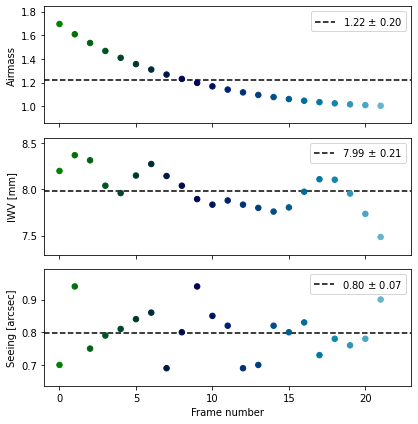

 Number of files: 30


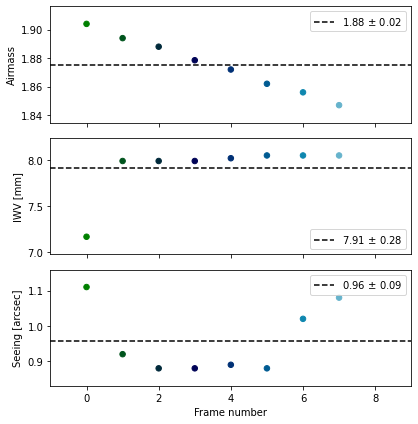

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
from astropy.io import fits

class ObservingConditions:
    
    
    header_dict = dict(
            obj      = 'OBJECT',
            date     = 'DATE-OBS',
            airmass_start = 'HIERARCH ESO TEL AIRM START',
            airmass_end = 'HIERARCH ESO TEL AIRM END',
            seeing   = 'ESO TEL IA FWHM', # [arcsec]
            iwv_start = 'HIERARCH ESO TEL AMBI IWV START', # Integrated water vapour [mm]
            iwv_end   = 'HIERARCH ESO TEL AMBI IWV END', # Integrated water vapour [mm]
            humidity = 'HIERARCH ESO TEL AMBI RHUM', # ambient relative humidity [%]
            ra       = 'RA',      # [deg]
            dec      = 'DEC',     # [deg]
            prog_id  = 'HIERARCH ESO OBS PROG ID',
        )
    
    def __init__(self, files):
        
        self.files = files
    
    def keys(self):
        return self.header_dict.keys()
    
    @property
    def unique_keys(self):
        # These keys we store as a single value (not a list)
        # return ['obj', 'instr','ra', 'dec', 'prog_id']
        return []
    
    def read_from_file(self, file):
        header = fits.getheader(file)
        for key in self.keys():
            setattr(self, key, header[self.header_dict[key]])
            
        [self.get_average(key=key_avg) for key_avg in ['airmass', 'iwv']]
        return self
    
    def get_average(self, key):
        mean = np.mean([getattr(self, key+label) for label in ['_start', '_end']], axis=0)
        setattr(self, key, mean)
        return self
        
    
    def read_from_files(self, files, obj=None):
        header_list = []
        # obj = obj is not None and obj or ''
        for f in files:
            with fits.open(f) as hdul:
                obj_i = hdul[0].header[self.header_dict['obj']]
                if obj is not None and obj_i == obj:
                    header_list.append(hdul[0].header)
                
        for key in self.keys():
            if key in self.unique_keys:
                setattr(self, key, header_list[0][self.header_dict[key]])
            else:
                setattr(self, key, [h[self.header_dict[key]] for h in header_list])
                
        [self.get_average(key=key_avg) for key_avg in ['airmass', 'iwv']]
        self.n_frames = len(header_list)
        return self
    
    def select_target(self, obj):
        
        assert hasattr(self, 'obj'), 'No object information available'
        assert obj in self.obj, f'Object {obj} not found in the list of objects'
        
        mask = np.array(self.obj) == obj
        print(f' Number of files for {obj}: {mask.sum()}')
        for key in self.keys():
            if key not in self.unique_keys:
                setattr(self, key, np.array(getattr(self, key))[mask])
        return self
    
    def plot(self, attr, ax=None, scatter=False, **kwargs):
        assert hasattr(self, attr), f'Attribute {attr} not found'
        if ax is None:
            fig, ax = plt.subplots()
            ax.set_xlabel('File number')
            
        if scatter:
            ax.scatter(range(len(getattr(self, attr))), getattr(self, attr), **kwargs)
        else:
            ax.plot(getattr(self, attr), **kwargs)
            
        ylabel = kwargs.pop('ylabel', attr)
        ax.set_ylabel(ylabel)
        return ax
    
def airmass(target,night):
    
    path = pathlib.Path('/home/natalie/Desktop/PhD/SupJup/data')
    #path = pathlib.Path('/media/natalie/Data2/SupJup_data')
    
    files = sorted((path/night/'raw').glob('CRIRES_SPEC_OBS*.fits'))
    print(f' Number of files: {len(files)}')

    obs = ObservingConditions(files)
    obs.read_from_files(files, obj=target)

    attrs = ['airmass', 
            'iwv',
            'seeing', 
            ]

    #print(obs.airmass)
    fig, ax = plt.subplots(len(attrs),1, figsize=(6,6), sharex=True, tight_layout=True)    
    cmap = 'ocean'
    colors = plt.cm.get_cmap(cmap)(np.linspace(0,0.8,obs.n_frames))
    
    labels = ['Airmass', 'IWV [mm]','Seeing [arcsec]']
    
    for i, attr in enumerate(attrs):
        obs.plot(attr, ax=ax[i], color=colors, scatter=True, s=30)
        avg = np.mean(getattr(obs, attr))
        std = np.std(getattr(obs, attr))
        # mean_std = np.mean(getattr(obs_std, attr))
        ax[i].axhline(avg, color='k', ls='--', zorder=0, label=f'{avg:.2f} $\pm$ {std:.2f}')
        
        # increase ylim by 10% of the range
        ylim = ax[i].get_ylim()
        ax[i].set_ylim(ylim[0]-0.15*np.diff(ylim), ylim[1] + 0.15*np.diff(ylim))
        
        ax[i].set_ylabel(labels[i])
        ax[i].legend()
    
    # obs.plot('airmass', scatter=True, ax=ax[0], color=colors)
    ax[-1].set_xlabel('Frame number')
    ax[-1].set_xlim(-1, obs.n_frames+1)
    plt.show()

n='2023-03-04_ROX'
airmass(target='ROXs 12',night =n)
#n='2023-03-04'
#airmass(target='2MASSI J0953212-101420',night =n)
airmass(target='i Sco',night =n)

/home/natalie/.local/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


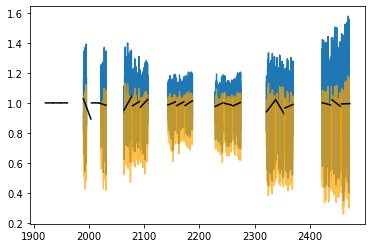

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import pathlib

def fit_continuum_1D(wl,fl,poly_order=3):
    nans = np.isnan(fl)
    if np.sum(nans)>(len(fl)-10):
        return np.ones_like(fl)
    continuum = np.poly1d(np.polyfit(wl[~nans],fl[~nans],poly_order))(wl)
    return continuum

def upper_envelope_contrem(wavelength, flux, min_valid_per_bin=250,
                        percentile=97, spline_smoothing=0.001):
    """
    Estimate continuum using adaptive binning based on non-NaN values.

    Parameters:
    - wavelength: 1D array of wavelengths
    - flux: 1D array of fluxes (can include NaNs)
    - min_valid_per_bin: minimum number of non-NaN points per bin
    - percentile: upper percentile to use for continuum points
    - spline_smoothing: smoothing parameter for the spline

    Returns:
    - continuum: estimated continuum over the full wavelength range
    """

    wavelength = np.asarray(wavelength)
    flux = np.asarray(flux)
    if np.isnan(flux).all():
        return flux
    if np.sum(np.isnan(flux))>1450:
        print('if np.sum(np.isnan(flux))>1450:')
        cont = fit_continuum_1D(wavelength,flux,poly_order=1)
        flux/=cont
        flux/=np.nanpercentile(flux,percentile)
        return flux
    elif np.sum(np.isnan(flux))>1000:
        print('elif np.sum(np.isnan(flux))>1000:')
        min_valid_per_bin = 50 #use smaller bins

    n = len(wavelength)
    i = 0

    max_waves, max_fluxes = [], []

    while i < n:
        j = i
        count = 0

        # Grow the bin until it has enough non-NaN values
        while j < n and count < min_valid_per_bin:
            if not (np.isnan(flux[j]) or np.isnan(wavelength[j])):
                count += 1
            j += 1

        if count == 0:
            i = j
            continue

        # Work with the valid bin
        w_bin = wavelength[i:j]
        f_bin = flux[i:j]
        mask = ~np.isnan(w_bin) & ~np.isnan(f_bin)
        w_clean = w_bin[mask]
        f_clean = f_bin[mask]

        if len(f_clean) == 0:
            i = j
            continue

        threshold = np.percentile(f_clean, percentile)
        idx = np.where(f_clean >= threshold)[0][0]

        max_waves.append(w_clean[idx])
        max_fluxes.append(f_clean[idx])

        # Move to next bin (non-overlapping)
        i = j

    if len(max_waves) < 4:
        return flux
        #raise ValueError("Too few continuum points extracted. Try lowering min_valid_per_bin or checking your data.")
    else:
        # Fit spline to the upper envelope
        spline = UnivariateSpline(max_waves, max_fluxes, s=spline_smoothing)
        continuum = spline(wavelength)

    flux/=continuum
    #plt.plot(wavelength,continuum,c='green')
    #flux/=np.nanmax(flux)

    return flux

n_pixels=2048
n_parts=21
file=pathlib.Path(f'CRIRES/ROXs12B/ROXs12B_spectrum.txt')
if file.exists():
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=np.reshape(file[:,0],(n_parts,n_pixels))
    fl=np.reshape(file[:,1],(n_parts,n_pixels))
    err=np.reshape(file[:,2],(n_parts,n_pixels))

plt.plot(wl.flatten(),fl.flatten())

for i in range(n_parts):
    #fl[i] = upper_envelope_contrem(wl[i],fl[i],percentile=93,min_valid_per_bin=400)
    cont = fit_continuum_1D(wl[i],fl[i],poly_order=1)
    fl[i]/=cont
    fl[i]/=np.nanpercentile(fl[i],97)
    plt.plot(wl[i],fl[i],alpha=0.7,c='orange')
    plt.plot(wl[i],cont,c='k')



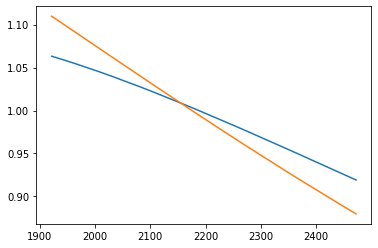

In [6]:
import numpy as np
from petitRADTRANS import nat_cst as nc
import matplotlib.pyplot as plt

def blackbody(wl,temp):
    lamb = wl*1e-7 # wavelength array in cms
    freq = nc.c / lamb # Convert to frequencies
    planck = nc.b(temp, freq) # Calculate Planck function at given temperature (K)
    planck=planck/np.mean(planck)
    return planck

def get_blackbody(comp,temp):

    file=np.genfromtxt(f'./CRIRES/ROXs12{comp}/ROXs12{comp}_spectrum.txt',skip_header=1,delimiter=' ')
    wl=file[:,0]
    bb=blackbody(wl,temp)
    plt.plot(wl,bb)
    spectrum=np.full(shape=(len(wl),3),fill_value=np.nan)
    spectrum[:,0]=wl
    spectrum[:,1]=bb
    np.savetxt(f'./CRIRES/ROXs12{comp}/ROXs12{comp}_continuum.txt',spectrum,delimiter=' ',header='wavelength (nm) flux')  

get_blackbody('B',3100)
get_blackbody('A',3900)

# Remove continuum with fft (data & model)

<ipython-input-6-ab7faf8817df>:184: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
<ipython-input-6-ab7faf8817df>:185: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show()


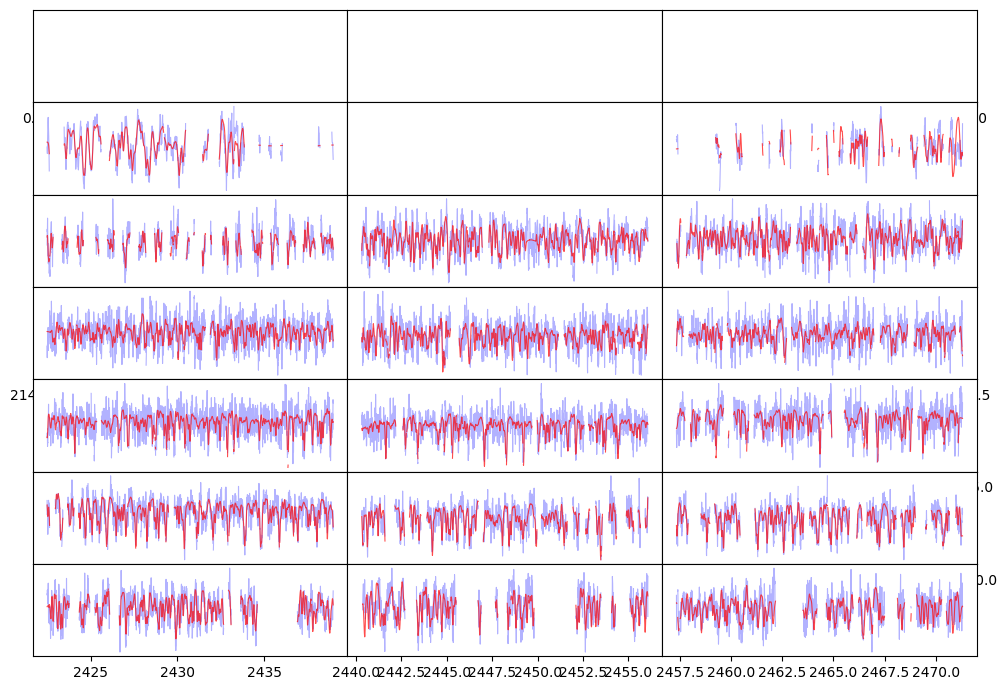

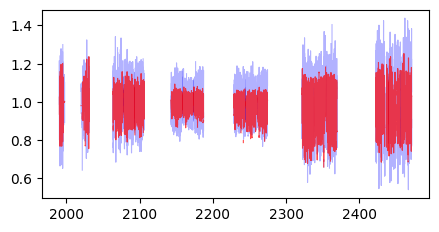

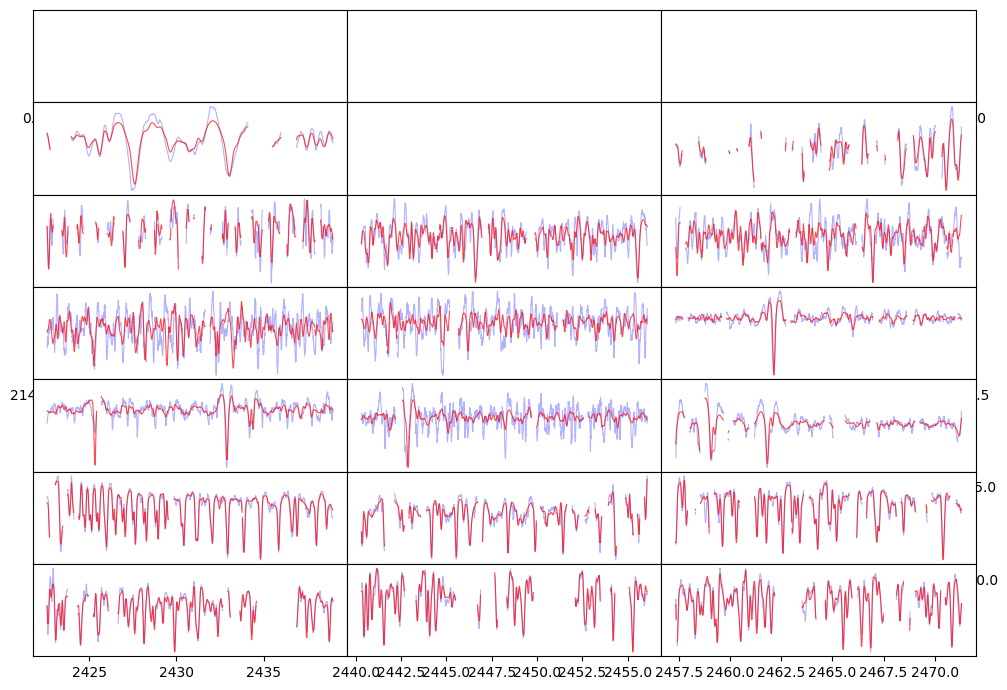

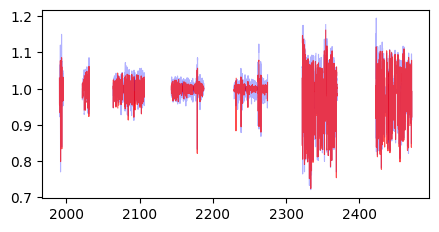

In [6]:
import os
os.environ['pRT_input_data_path'] = "/home/natalie/.local/lib/python3.8/site-packages/petitRADTRANS/input_data_std/input_data"
from target import Target
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline

def load_spectrum(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=file[:,0].reshape(7*3,2048)
    fl=file[:,1].reshape(7*3,2048)
    return wl,fl

def interpolate_nans(y):
    nans = np.isnan(y)
    if np.any(nans):
        not_nan = ~nans
        y[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(not_nan), y[not_nan])
    return y

def remove_continuum_fft(flux,low_cutoff =0.005,high_cutoff = 0.1):
    f = interpolate_nans(flux) # required for fft, can't handle nans

    # Apply FFT to smoothed spectrum
    f_fft = np.fft.fft(f)
    N = len(f)
    freq = np.fft.fftfreq(N)

    # Band-pass filter - keep only mid-frequency range
    low_cutoff = low_cutoff   # Remove very low frequencies (continuum)
    high_cutoff = high_cutoff    # Remove high frequencies (noise)
    band_pass_mask = (np.abs(freq) > low_cutoff) #& (np.abs(freq) < high_cutoff)
    filtered_fft = f_fft * band_pass_mask

    # Inverse FFT to get filtered spectrum
    f_contrem = np.fft.ifft(filtered_fft).real+np.ones(N)
    #f_contrem/=np.nanpercentile(f_contrem,50)
    return f_contrem

def fit_continuum_1D(wl,spec,poly_order=3):
    nans = np.isnan(spec)
    if np.sum(nans)>(len(spec)-10):
        return np.ones_like(spec)
    continuum = np.poly1d(np.polyfit(wl[~nans],spec[~nans],poly_order))(wl)
    return continuum

def upper_envelope_contrem(wavelength, spectrum, min_valid_per_bin=250,
                        percentile=97, spline_smoothing=0.001, oneD=False):

    wavelength = np.asarray(wavelength)
    flux = np.asarray(spectrum)
    if np.isnan(flux).all():
        return flux
    if np.sum(np.isnan(flux))>1450 or oneD==True:
        cont = fit_continuum_1D(wavelength,flux,poly_order=1)
        flux/=cont
        flux/=np.nanpercentile(flux,percentile)
        return flux
    elif np.sum(np.isnan(flux))>1000:
        min_valid_per_bin = 50 #use smaller bins

    n = len(wavelength)
    i = 0
    max_waves, max_fluxes = [], []

    while i < n:
        j = i
        count = 0
        while j < n and count < min_valid_per_bin:
            if not (np.isnan(flux[j]) or np.isnan(wavelength[j])):
                count += 1
            j += 1

        if count == 0:
            i = j
            continue

        w_bin = wavelength[i:j]
        f_bin = flux[i:j]
        mask = ~np.isnan(w_bin) & ~np.isnan(f_bin)
        w_clean = w_bin[mask]
        f_clean = f_bin[mask]
        if len(f_clean) == 0:
            i = j
            continue

        threshold = np.percentile(f_clean, percentile)
        idx = np.where(f_clean >= threshold)[0][0]
        max_waves.append(w_clean[idx])
        max_fluxes.append(f_clean[idx])
        i = j

    if len(max_waves) < 4:
        return flux
        #raise ValueError("Too few continuum points extracted. Try lowering min_valid_per_bin or checking your data.")
    else:
        # Fit spline to the upper envelope
        spline = UnivariateSpline(max_waves, max_fluxes, s=spline_smoothing)
        continuum = spline(wavelength)

    flux/=continuum
    flux/=np.nanpercentile(flux,percentile)
    return flux

def remove_continuum_fft_new(flux, lower_cutoff=13):
    flux = np.asarray(flux)
    n = len(flux)
    
    # can't handle NaNs
    isnan = np.isnan(flux)
    if np.any(isnan):
        flux = np.interp(np.arange(n), np.arange(n)[~isnan], flux[~isnan])

    # FFT and filtering
    fft_flux = np.fft.rfft(flux)
    fft_flux[:lower_cutoff] = 0  # remove low-frequency continuum
    filtered = np.fft.irfft(fft_flux, n=n) + np.ones(n)
    
    return filtered

def remove_continuum_flux(wave,flux,percentile=97,**kwargs):
    fig,axes=plt.subplots(7,3,figsize=(10,7),dpi=100)
    fig2,axes2=plt.subplots(1,1,figsize=(5,2.5),dpi=100)
    if 'flux_model' in kwargs: # flux model
        flux_model = kwargs['flux_model']
    i = 0
    for o in range(7):
        for d in range(3):
            w = wave[i]
            f = np.copy(flux[i])
            mask = np.isfinite(f)

            ax=axes[o,d] 
            ax.set_yticks([])

            # Start by removing frequencies below ~1/100 to 1/200 of the array length, i.e.:
            lower_cutoff = len(f) // 150  # ≈ 13
            #print(lower_cutoff)
            #lower_cutoff = int(1)
            if np.isnan(f).all():
                i +=1
                continue

            f_contrem = upper_envelope_contrem(w,f,oneD=True)#percentile=percentile,min_valid_per_bin=300,spline_smoothing=0.01)
            #f_fft = remove_continuum_fft(f,low_cutoff = 0.01,high_cutoff = 0.5)
            f_fft = remove_continuum_fft_new(f,lower_cutoff = lower_cutoff)
            #low=0.005
            #f_fft = remove_continuum_fft(f,low_cutoff=low)

            if 'flux_model' in kwargs:
                flm = np.copy(flux_model[i])
                flm[~mask]=np.nan
                fm_fft = remove_continuum_fft_new(flm,lower_cutoff = lower_cutoff)
                #fm_fft = remove_continuum_fft(flm,low_cutoff=low)

            #flux[i]/=np.nanpercentile(flux[i],percentile)
            #f_contrem/=np.nanpercentile(f_contrem,percentile)
            #f_fft/=np.nanpercentile(f_fft,percentile)

            for flx in [f,f_contrem,f_fft]:
                flx[~mask]=np.nan
            
            #ax.plot(w,flux[i],c='b',alpha=0.3,lw=0.8)
            #ax.plot(w,f_contrem,c='k',alpha=0.7,lw=0.8)
            ax.plot(w,f_fft,c='b',alpha=0.3,lw=0.8)
            #ax.plot(w,flux[i]-f_contrem,c='b',alpha=0.3,lw=0.8)
            #ax.plot(w,flux[i]-f_fft,c='b',alpha=0.3,lw=0.8)

            #axes2.plot(w[mask],flux[i][mask],c='b',alpha=0.4,lw=0.8)
            #axes2.plot(w[mask],f_contrem[mask],c='k',alpha=0.7,lw=0.8)
            axes2.plot(w,f_fft,c='b',alpha=0.3,lw=0.8)
            #axes2.plot(w[mask],flux[i][mask]-f_contrem[mask],c='b',alpha=0.4,lw=0.8)
            #axes2.plot(w[mask],flux[i][mask]-f_fft[mask],c='b',alpha=0.4,lw=0.8)

            if 'flux_model' in kwargs:
                fm_fft[~mask]=np.nan
                ax.plot(w,fm_fft,c='r',alpha=0.7,lw=0.8)
                axes2.plot(w,fm_fft,c='r',alpha=0.7,lw=0.8)
            i+=1

    fig.tight_layout()
    fig.subplots_adjust(wspace=0, hspace=0)
    fig.show()
    fig2.show()

# with np.fft, OK as long as data and model weird in same way
wlm,flm = load_spectrum('CRIRES/ROXs12B/bestfit_spectrum.txt')
wld,fld,errd = Target('ROXs12B').load_spectrum()
remove_continuum_flux(wld,fld,flux_model=flm,percentile=85) # data noisy

wlm,flm = load_spectrum('CRIRES/ROXs12A/bestfit_spectrum.txt')
wld,fld,errd = Target('ROXs12A').load_spectrum()
remove_continuum_flux(wld,fld,flux_model=flm,percentile=97)

# Introduce physical slope in flux A from a preliminary model of A

<ipython-input-33-d173a0236bb6>:67: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
<ipython-input-33-d173a0236bb6>:68: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show()


1.0


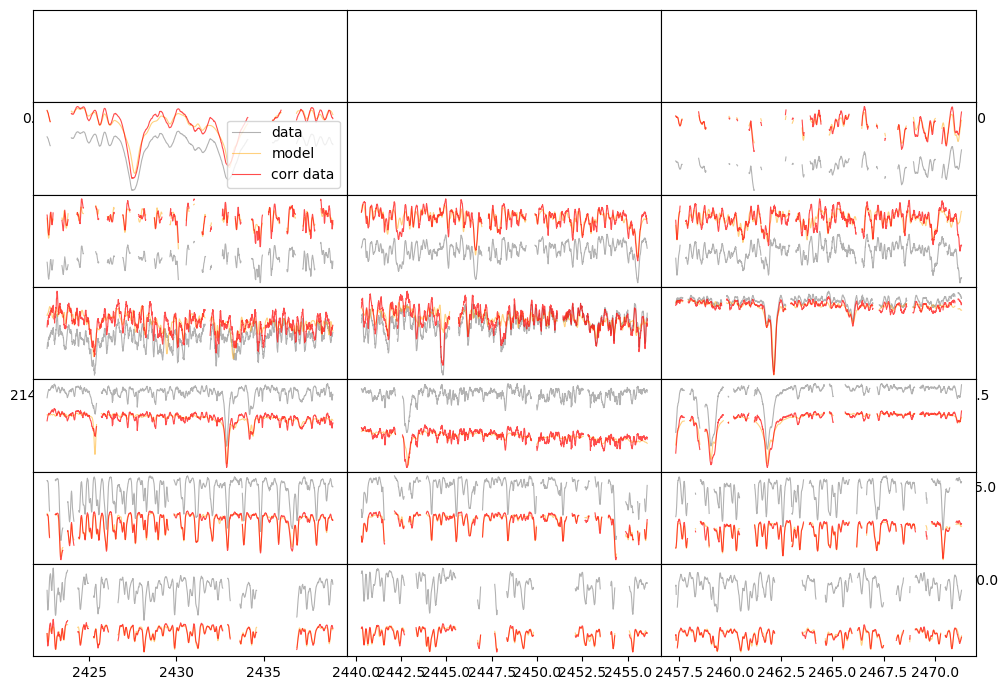

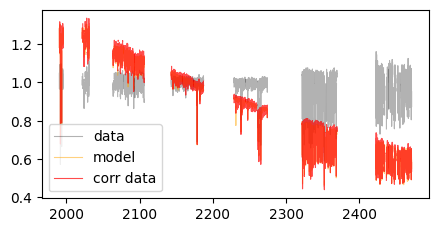

In [ ]:
from math import erf
import os
os.environ['pRT_input_data_path'] = "/home/natalie/.local/lib/python3.8/site-packages/petitRADTRANS/input_data_std/input_data"
import numpy as np
import matplotlib.pyplot as plt

model_A = '/home/natalie/Desktop/atm_retrieval/CRIRES/ROXs12A/ROXs12A_pRTflux_wslope.txt'
data_A = '/home/natalie/Desktop/atm_retrieval/CRIRES/ROXs12A/ROXs12A_spectrum.txt'

n_parts=21
n_pixels=2048
def load_spectrum(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=np.reshape(file[:,0],(n_parts,n_pixels))
    fl=np.reshape(file[:,1],(n_parts,n_pixels))
    return wl,fl

waveA,flxA=load_spectrum(data_A)
flxAm=np.reshape(np.genfromtxt(model_A),(n_parts,n_pixels))

fig,axes=plt.subplots(7,3,figsize=(10,7),dpi=100)
fig2,axes2=plt.subplots(1,1,figsize=(5,2.5),dpi=100)

i = 0
norm_factor = np.nanpercentile(flxAm,50) # use same for all ord/det!!
flux_sloped = np.full((7,3,2048),fill_value=np.nan)

for o in range(7):
    for d in range(3):
        w = waveA[i]
        f = np.copy(flxA[i])
        fm  = np.copy(flxAm[i])
        nans = ~np.isfinite(f)

        ax=axes[o,d] 
        ax.set_yticks([])

        if np.isnan(f).all():
            i +=1
            continue

        f[nans]=np.nan
        fm[nans]=np.nan

        # divide data of A through model of A
        f_div = f/fm

        # fit second order polynomnial to result
        coeffs = np.polyfit(w[~nans], f_div[~nans], deg=2)
        res_fit = np.poly1d(coeffs)(w)

        # divide data through polynomial to get blaze-corrected spectrum of star
        f_corr = f/res_fit
        flux_sloped[o,d] = f_corr/norm_factor

        for a in [ax,axes2]:
            a.plot(w,f,c='k',alpha=0.3,lw=0.8,label='data')
            a.plot(w,fm/norm_factor,c='orange',alpha=0.5,lw=0.8,label='model')
            a.plot(w,f_corr/norm_factor,c='r',alpha=0.7,lw=0.8,label='corr data')
        if o==1 and d==0:
            ax.legend()
            axes2.legend()
        i+=1

fig.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.show()
fig2.show()

flux_sloped/=np.nanmedian(flux_sloped)
spectrum=np.full(shape=(len(waveA.flatten()),1),fill_value=np.nan)
spectrum[:,0]=flux_sloped.flatten()
np.savetxt('./CRIRES/ROXs12A/ROXs12A_dataflux_wslope.txt',spectrum)


In [23]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy import constants as const
import numpy as np
from scipy.ndimage import gaussian_filter


data_A = '/home/natalie/Desktop/atm_retrieval/CRIRES/ROXs12A/ROXs12A_sloped_spectrum.txt'
n_parts=21
n_pixels=2048
def load_spectrum(file):
    file=np.genfromtxt(file,skip_header=1,delimiter=' ')
    wl=np.reshape(file[:,0],(n_parts,n_pixels))
    fl=np.reshape(file[:,1],(n_parts,n_pixels))
    return wl,fl
waveA,flxA=load_spectrum(data_A)
xmin,xmax=2330,2370
xmin,xmax=2330,2470
wl = fits.open(f'./CRIRES/ROXs12A/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits')[0].data/10 # in nm
mask_CRIRES_Range = (wl>1900)&(wl<2500)

def convolve_to_resolution(in_wlen, in_flux, out_res, in_res=None):

    if in_res is None:
        in_res = np.mean((in_wlen[:-1]/np.diff(in_wlen)))
    # delta lambda of resolution element is FWHM of the LSF's standard deviation:
    sigma_LSF = np.sqrt(1./out_res**2-1./in_res**2)/(2.*np.sqrt(2.*np.log(2.)))
    spacing = np.mean(2.*np.diff(in_wlen)/(in_wlen[1:]+in_wlen[:-1]))

    # Calculate the sigma to be used in the gauss filter in pixels
    sigma_LSF_gauss_filter = sigma_LSF/spacing
    out_flux = np.tile(np.nan, in_flux.shape)
    nans = np.isnan(in_flux)
    out_flux[~nans] = gaussian_filter(in_flux[~nans], sigma = sigma_LSF_gauss_filter, mode = 'reflect')

    return out_flux

# https://phoenix.astro.physik.uni-goettingen.de/?page_id=15
def load_PHOENIX(metall):
    hdul = fits.open(f'./CRIRES/ROXs12A/lte04000-4.00-{metall}.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits')
    flux = hdul[0].data    # In erg/s/cm^2/Å
    flux = flux[mask_CRIRES_Range]
    wl_nm = wl[mask_CRIRES_Range]
    flux/=np.median(flux)
    mask = (wl_nm>xmin)&(wl_nm<xmax)
    wl_nm = wl_nm[mask]
    flux = flux[mask]
    flux = convolve_to_resolution(wl_nm,flux,60000)
    return wl_nm,flux

wl0, fl0 = load_PHOENIX(int(0))
wl1, fl1 = load_PHOENIX(int(1))

maskA = (waveA>xmin)&(waveA<xmax)
waveA = waveA[maskA].flatten()
flxA = flxA[maskA].flatten()
vbary = 30.097617580649505
rv = -5.8
wl_shifted= waveA*(1.0+(rv-vbary)/const.c.to('km/s').value)
waves_even = np.linspace(np.min(waveA), np.max(waveA), waveA.size) # wavelength array has to be regularly spaced
flxA_shifted = np.interp(waves_even, wl_shifted, flxA)

plt.figure(figsize=(6, 4),dpi=150)
plt.plot(wl0, fl0, label="[M/H] = 0", lw=0.8,c='r')
plt.plot(wl1, fl1, label="[M/H] = -1", lw=0.8,c='y')
plt.plot(waveA,flxA,lw=0.8,label='Data w/ slope',c='k')
#plt.plot(wl_shifted,flxA_shifted,lw=0.8,label='Data w/ slope',c='k')

plt.xlim(2341,2364)

plt.xlabel("Wavelength [nm]")
plt.title("PHOENIX Spectrum at Teff = 4000 K")
plt.legend()
plt.tight_layout()

FileNotFoundError: /home/natalie/Desktop/atm_retrieval/CRIRES/ROXs12A/ROXs12A_sloped_spectrum.txt not found.

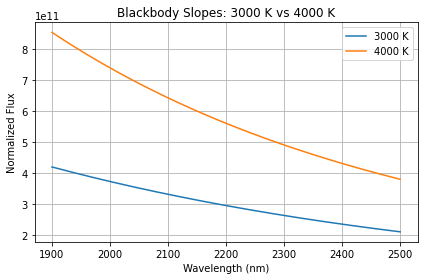

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k

def planck(wavelength_m, T):
    return (2*h*c**2 / wavelength_m**5) / (np.exp(h*c / (wavelength_m*k*T)) - 1)

wl_nm = np.linspace(1900, 2500, 500)
wl_m = wl_nm * 1e-9

bb_3000 = planck(wl_m, 3000)
bb_4000 = planck(wl_m, 4000)

#plt.plot(wl_nm, bb_3000 / np.max(bb_3000), label='3000 K')
#plt.plot(wl_nm, bb_4000 / np.max(bb_4000), label='4000 K')
plt.plot(wl_nm, bb_3000, label='3000 K')
plt.plot(wl_nm, bb_4000, label='4000 K')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Flux')
plt.title('Blackbody Slopes: 3000 K vs 4000 K')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
